<a href="https://colab.research.google.com/github/Sakshi-HC-Gowda/Data-Science-and-Gen-AI/blob/main/Day_5_Gen_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import sklearn

In [ ]:
from sklearn import datasets

In [ ]:
BC = datasets.load_breast_cancer()

In [ ]:
BC

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
df = pd.DataFrame(data = BC['data'],columns=BC['feature_names'])
df['Cancer_Type'] = BC['target']
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Cancer_Type
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.tree import DecisionTreeClassifier
reg = DecisionTreeClassifier(criterion='entropy')
reg.fit(X_train,y_train)  # training

# Training performance

print('Train Performance')
y_train_pred = reg.predict(X_train)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print(f'Confusion Matrix: {confusion_matrix(y_train,y_train_pred)}')
print(f'Classification Report: {classification_report(y_train,y_train_pred)}')
print(f'Accuracy Score: {accuracy_score(y_train,y_train_pred)}')

print('------------------------------------------------------------------------------------------------')

y_test_pred = reg.predict(X_test)
print('Test performance')
print(f'Confusion Matrix: {confusion_matrix(y_test,y_test_pred)}')
print(f'Classification Report: {classification_report(y_test,y_test_pred)}')
print(f'Accuracy Score: {accuracy_score(y_test,y_test_pred)}')

Train Performance
Confusion Matrix: [[169   0]
 [  0 286]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       169
           1       1.00      1.00      1.00       286

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455

Accuracy Score: 1.0
------------------------------------------------------------------------------------------------
Test performance
Confusion Matrix: [[39  4]
 [ 1 70]]
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy Score: 0.956140350877193


In [ ]:
# Random forest

from sklearn.ensemble import RandomForestClassifier
reg1 = RandomForestClassifier(n_estimators=11,criterion='entropy')
reg1.fit(X_train,y_train)

y_train_pred = reg1.predict(X_train)

print(f'Confusion Matrix: {confusion_matrix(y_train,y_train_pred)}')
print(f'Classification Report: {classification_report(y_train,y_train_pred)}')
print(f'Accuracy Score: {accuracy_score(y_train,y_train_pred)}')

print('------------------------------------------------------------------------------------------------')

y_test_pred = reg1.predict(X_test)
print('Test performance')
print(f'Confusion Matrix: {confusion_matrix(y_test,y_test_pred)}')
print(f'Classification Report: {classification_report(y_test,y_test_pred)}')
print(f'Accuracy Score: {accuracy_score(y_test,y_test_pred)}')

Confusion Matrix: [[169   0]
 [  0 286]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       169
           1       1.00      1.00      1.00       286

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455

Accuracy Score: 1.0
------------------------------------------------------------------------------------------------
Test performance
Confusion Matrix: [[40  3]
 [ 1 70]]
Classification Report:               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Accuracy Score: 0.9649122807017544


In [ ]:
a = np.random.random((500,12))
sampledata = pd.DataFrame(a)
sampledata.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.348066,0.875588,0.367508,0.170095,0.743043,0.362454,0.905178,0.610985,0.216551,0.803969,0.663132,0.477272
1,0.837920,0.426248,0.752741,0.374946,0.128340,0.632352,0.739489,0.179186,0.744868,0.216377,0.199454,0.502175
2,0.891515,0.493909,0.071160,0.374058,0.608404,0.507858,0.589369,0.152694,0.306770,0.555131,0.044985,0.725249
3,0.235984,0.352380,0.923888,0.646582,0.733839,0.808069,0.477424,0.692285,0.516986,0.442773,0.690733,0.352295
4,0.580534,0.587825,0.745607,0.082240,0.151438,0.711642,0.274043,0.714193,0.736789,0.701576,0.882988,0.602389


In [ ]:
sampledata.shape

(500, 12)

In [ ]:
values = []

for i in range(500):
  if i > 249:
    values.append(1)
  else:
    values.append(0)

In [ ]:
len(values)

500

In [ ]:
sampledata['Target'] = values

In [ ]:
sampledata.sample(10)

,0,1,2,3,4,5,6,7,8,9,10,11,Target
401,0.935790,0.417016,0.054474,0.283826,0.668957,0.832817,0.287534,0.942946,0.284632,0.252827,0.064012,0.440992,1
457,0.702975,0.478546,0.649941,0.173995,0.952185,0.545410,0.587911,0.698468,0.634149,0.284703,0.314988,0.664188,1
389,0.038247,0.394426,0.762254,0.590977,0.745806,0.168542,0.675552,0.006288,0.863246,0.597492,0.551581,0.916720,1
302,0.900497,0.059144,0.332193,0.385087,0.138444,0.558057,0.732841,0.655665,0.860470,0.923094,0.429156,0.847294,1
450,0.043228,0.559138,0.619117,0.740298,0.159438,0.365325,0.531043,0.475281,0.600976,0.541734,0.149826,0.588639,1
260,0.263894,0.564984,0.990909,0.701468,0.484647,0.866583,0.635444,0.799288,0.588858,0.683775,0.215225,0.135241,1
222,0.699093,0.884701,0.126012,0.769652,0.004175,0.969841,0.798847,0.244422,0.149697,0.844094,0.953047,0.602635,0
57,0.019391,0.057907,0.118797,0.127742,0.884795,0.204729,0.142989,0.285669,0.324541,0.399012,0.056894,0.873964,0
105,0.364606,0.174061,0.440140,0.349405,0.255081,0.144375,0.064144,0.911372,0.856326,0.984439,0.673010,0.179251,0
255,0.303629,0.677510,0.078320,0.721935,0.714535,0.633441,0.838078,0.168758,0.307289,0.532925,0.524669,0.685655,1


In [ ]:
X = sampledata.iloc[:,:-1]
y = sampledata.iloc[:,-1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
len(X_test),len(y_test)

(100, 100)

In [ ]:
# Adaboost

from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

reg2 = AdaBoostClassifier(estimator=log_reg,n_estimators=10,learning_rate=0.01)
reg2.fit(X_train,y_train)

print(reg2.score(X_train,y_train))
print(reg2.score(X_test,y_test))

0.51
0.46


In [ ]:
l = [10,23,35,47,83]
lr = [0.1,0.01,0.02,0.3,0.2]

for i in l:
  for j in lr:
    reg2 = AdaBoostClassifier(estimator=log_reg,n_estimators=i,learning_rate=j)
    reg2.fit(X_train,y_train)

    print(f'Training accuracy if n_estimators are {i} - {reg2.score(X_train,y_train)}')
    print(f'testing accuracy if n_estimators are {i} - {reg2.score(X_test,y_test)}')
    print('-------------------------------------------------------------------------')

Training accuracy if n_estimators are 10 - 0.51
testing accuracy if n_estimators are 10 - 0.46
-------------------------------------------------------------------------
Training accuracy if n_estimators are 10 - 0.51
testing accuracy if n_estimators are 10 - 0.46
-------------------------------------------------------------------------
Training accuracy if n_estimators are 10 - 0.51
testing accuracy if n_estimators are 10 - 0.46
-------------------------------------------------------------------------
Training accuracy if n_estimators are 10 - 0.5475
testing accuracy if n_estimators are 10 - 0.62
-------------------------------------------------------------------------
Training accuracy if n_estimators are 10 - 0.555
testing accuracy if n_estimators are 10 - 0.64
-------------------------------------------------------------------------
Training accuracy if n_estimators are 23 - 0.555
testing accuracy if n_estimators are 23 - 0.63
--------------------------------------------------------

In [ ]:
#XGBoost

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from xgboost import XGBClassifier



In [ ]:
X,y = make_classification(
    n_samples = 1000,
    n_features = 20,
    n_informative = 15,
    random_state = 42
)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [ ]:
XG = XGBClassifier(
    n_estimators = 100,
    max_depth = 5,
    learning_rate = 0.1,
    random_state = 42
)

XG.fit(X_train, y_train)

y_train_predictions = XG.predict(X_train)

y_test_predictions = XG.predict(X_test)

print(f'Training Accuracy is: {accuracy_score(y_train,y_train_predictions)}')
print(f'Testing Accuracy is: {accuracy_score(y_test,y_test_predictions)}')

Training Accuracy is: 1.0
Testing Accuracy is: 0.87


**Feature Engineering**

- Handling Missing Values
- Encoding Categorical Features
- Handling Outliers
- Feature scaling (Normalization and Standardization)
- Log Transformation

In [ ]:
import pandas as pd

df = pd.DataFrame({'Age':[10,20,30,None,50]})
df

,Age
0,10.0
1,20.0
2,30.0
3,NaN
4,50.0


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [ ]:
df

,Age
0,10.0
1,20.0
2,30.0
3,25.0
4,50.0


In [ ]:
df['Age'].median()

25.0

In [ ]:
# Raw data -> Feature Engineering -> Better data -> Better Model

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols['gender'] = le.fit_transform(cat_cols['gender'])   # binary , ordinal



In [ ]:
# One Hot Encoding

# North South East West
#  1      0     0     0
#  0      1     0     0
#  0      0     1     0
#  0      0     0     1

In [ ]:
sd = pd.DataFrame({'Region':['North','South','East','West']})

In [ ]:
sd

,Region
0,North
1,South
2,East
3,West


In [ ]:
encoded = pd.get_dummies(sd, columns = ['Region'],dtype=int)
print(encoded)

   Region_East  Region_North  Region_South  Region_West
0            0             1             0            0
1            0             0             1            0
2            1             0             0            0
3            0             0             0            1


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoded1 = encoder.fit_transform(df['Age'])

In [ ]:
# Outliers



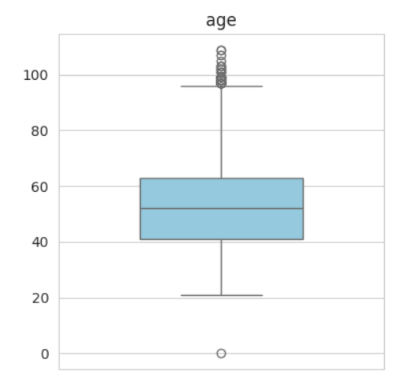

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3-Q1